In [ ]:
import pygmt
import numpy as np
import xarray as xr
from pygmt.clib import Session

In [2]:
paths = {'NEMO': '/results2/SalishSea/nowcast-green.202111/',
         'coords': '/ocean/jvalenti/MOAD/grid/coordinates_seagrid_SalishSea201702.nc',
         'coordsWW3': '/ocean/jvalenti/MOAD/grid2/WW3_grid.nc',
         'mask': '/ocean/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc',
         'bat': '/ocean/jvalenti/MOAD/grid/bathymetry_202108.nc',
         'out': '/home/jvalenti/MOAD/results',
         'home': '/home/jvalenti/MOAD/analysis-jose/notebooks/parcels'}

In [3]:
coords = xr.open_dataset(paths['coords'], decode_times=False)
mask = xr.open_dataset(paths['mask'])

In [ ]:
# ------------------------------------------------------------------
# 1. Regridding: NEMO's nav_lon/nav_lat are curvilinear, not a regular
#    lon/lat grid, so GMT's grdimage/grdcontour need this done once.
# ------------------------------------------------------------------
def curvilinear_to_grid(lon2d, lat2d, z2d, spacing, region):
    lon, lat, z = lon2d.values.ravel(), lat2d.values.ravel(), z2d.values.ravel()
    good = np.isfinite(z)
    return pygmt.nearneighbor(
        x=lon[good], y=lat[good], z=z[good],
        spacing=spacing, region=region, search_radius=f"{spacing*2}d",
    )

region = [
    float(coords.nav_lon.min()), float(coords.nav_lon.max()),
    float(coords.nav_lat.min()), float(coords.nav_lat.max()),
]
spacing = 0.005  # tune to your native model resolution

bathy_grid = curvilinear_to_grid(coords.nav_lon, coords.nav_lat, mask.totaldepth, spacing, region)
#bathy_grid.to_netcdf("bathy_regridded.nc")

umask_grid = curvilinear_to_grid(coords.nav_lon, coords.nav_lat, mask.tmask[0, 0], spacing, region)
#umask_grid.to_netcdf("landmask_regridded.nc")

# ------------------------------------------------------------------
# 2. Domain footprint polygon (walk the four edges of the curvilinear
#    grid) — used both to restrict the land-mask overlay and for the
#    minimap inset outline.
# ------------------------------------------------------------------
from matplotlib.path import Path

lon_b = np.r_[coords.nav_lon[0, :], coords.nav_lon[:, -1],
              coords.nav_lon[-1, ::-1], coords.nav_lon[::-1, 0]]
lat_b = np.r_[coords.nav_lat[0, :], coords.nav_lat[:, -1],
              coords.nav_lat[-1, ::-1], coords.nav_lat[::-1, 0]]

umask_da = xr.open_dataarray("landmask_regridded.nc")

# Build the coordinate grid that umask_da 
ny_name, nx_name = umask_da.dims
lon_vals = umask_da[nx_name].values
lat_vals = umask_da[ny_name].values
lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)

domain_path = Path(np.column_stack([lon_b, lat_b]))
inside = domain_path.contains_points(
    np.column_stack([lon2d.ravel(), lat2d.ravel()])
).reshape(lon2d.shape)

mask_bool = (umask_da.values < 0.5) & inside
land_in_domain = umask_da.copy(data=np.where(mask_bool, umask_da.values, np.nan))


relief = pygmt.datasets.load_earth_relief(resolution="03s", region=region)
relief_rs = pygmt.grdsample(grid=relief, region=region, spacing=spacing)

bathy_da = xr.open_dataarray("bathy_regridded.nc")
relief_arr = relief_rs.reindex_like(bathy_da, method="nearest").values

is_water = np.isfinite(bathy_da.values)
combined = bathy_da.copy(data=np.where(is_water, -bathy_da.values, relief_arr))
combined.to_netcdf("combined_topo_bathy.nc")


domain_field = umask_da.copy(data=np.where(inside, umask_da.values, np.nan))

nearneighbor [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
nearneighbor [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
nearneighbor (gmtapi_init_grdheader): Please select compatible -R and -I values
nearneighbor [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
nearneighbor [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
nearneighbor (gmtapi_init_grdheader): Please select compatible -R and -I values
grdsample [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdsample [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdsample (gmtapi_init_grdheader): Please select compatible -R and -I values
grdsample [WARNING]: Output sampling interval in x exceeds input interval and may lea

In [ ]:
import matplotlib.pyplot as plt

cs_line = plt.contour(coords.nav_lon, coords.nav_lat, mask.umask[0, 0], levels=[0])
plt.close('all')

coast_lines = cs_line.allsegs[0]    

In [ ]:
from shapely.geometry import Polygon, MultiPolygon
from shapely.strtree import STRtree
import geopandas as gpd

def ring_signed_area(ring):
    x, y = ring[:, 0], ring[:, 1]
    return 0.5 * np.sum(x[:-1] * y[1:] - x[1:] * y[:-1])

# Re-trace, but read the Path objects directly (they preserve hole info)
cs_fill = plt.contourf(coords.nav_lon, coords.nav_lat, mask.tmask[0, 0], levels=[-0.5, 0.5])
plt.close('all')

exteriors, holes = [], []
for path in cs_fill.get_paths():
    for ring in path.to_polygons():
        if len(ring) < 4:
            continue
        (exteriors if ring_signed_area(ring) > 0 else holes).append(ring)

ext_polys = [Polygon(r) for r in exteriors]
tree = STRtree(ext_polys)

holes_by_ext = {i: [] for i in range(len(ext_polys))}
for h in holes:
    pt = Polygon(h).representative_point()
    for idx in np.atleast_1d(tree.query(pt)):
        idx = int(idx)
        if ext_polys[idx].contains(pt):
            holes_by_ext[idx].append(h)
            break

land_shape = MultiPolygon([Polygon(exteriors[i], holes_by_ext[i]) for i in range(len(ext_polys))])
gdf = gpd.GeoDataFrame(geometry=[land_shape], crs="EPSG:4326")

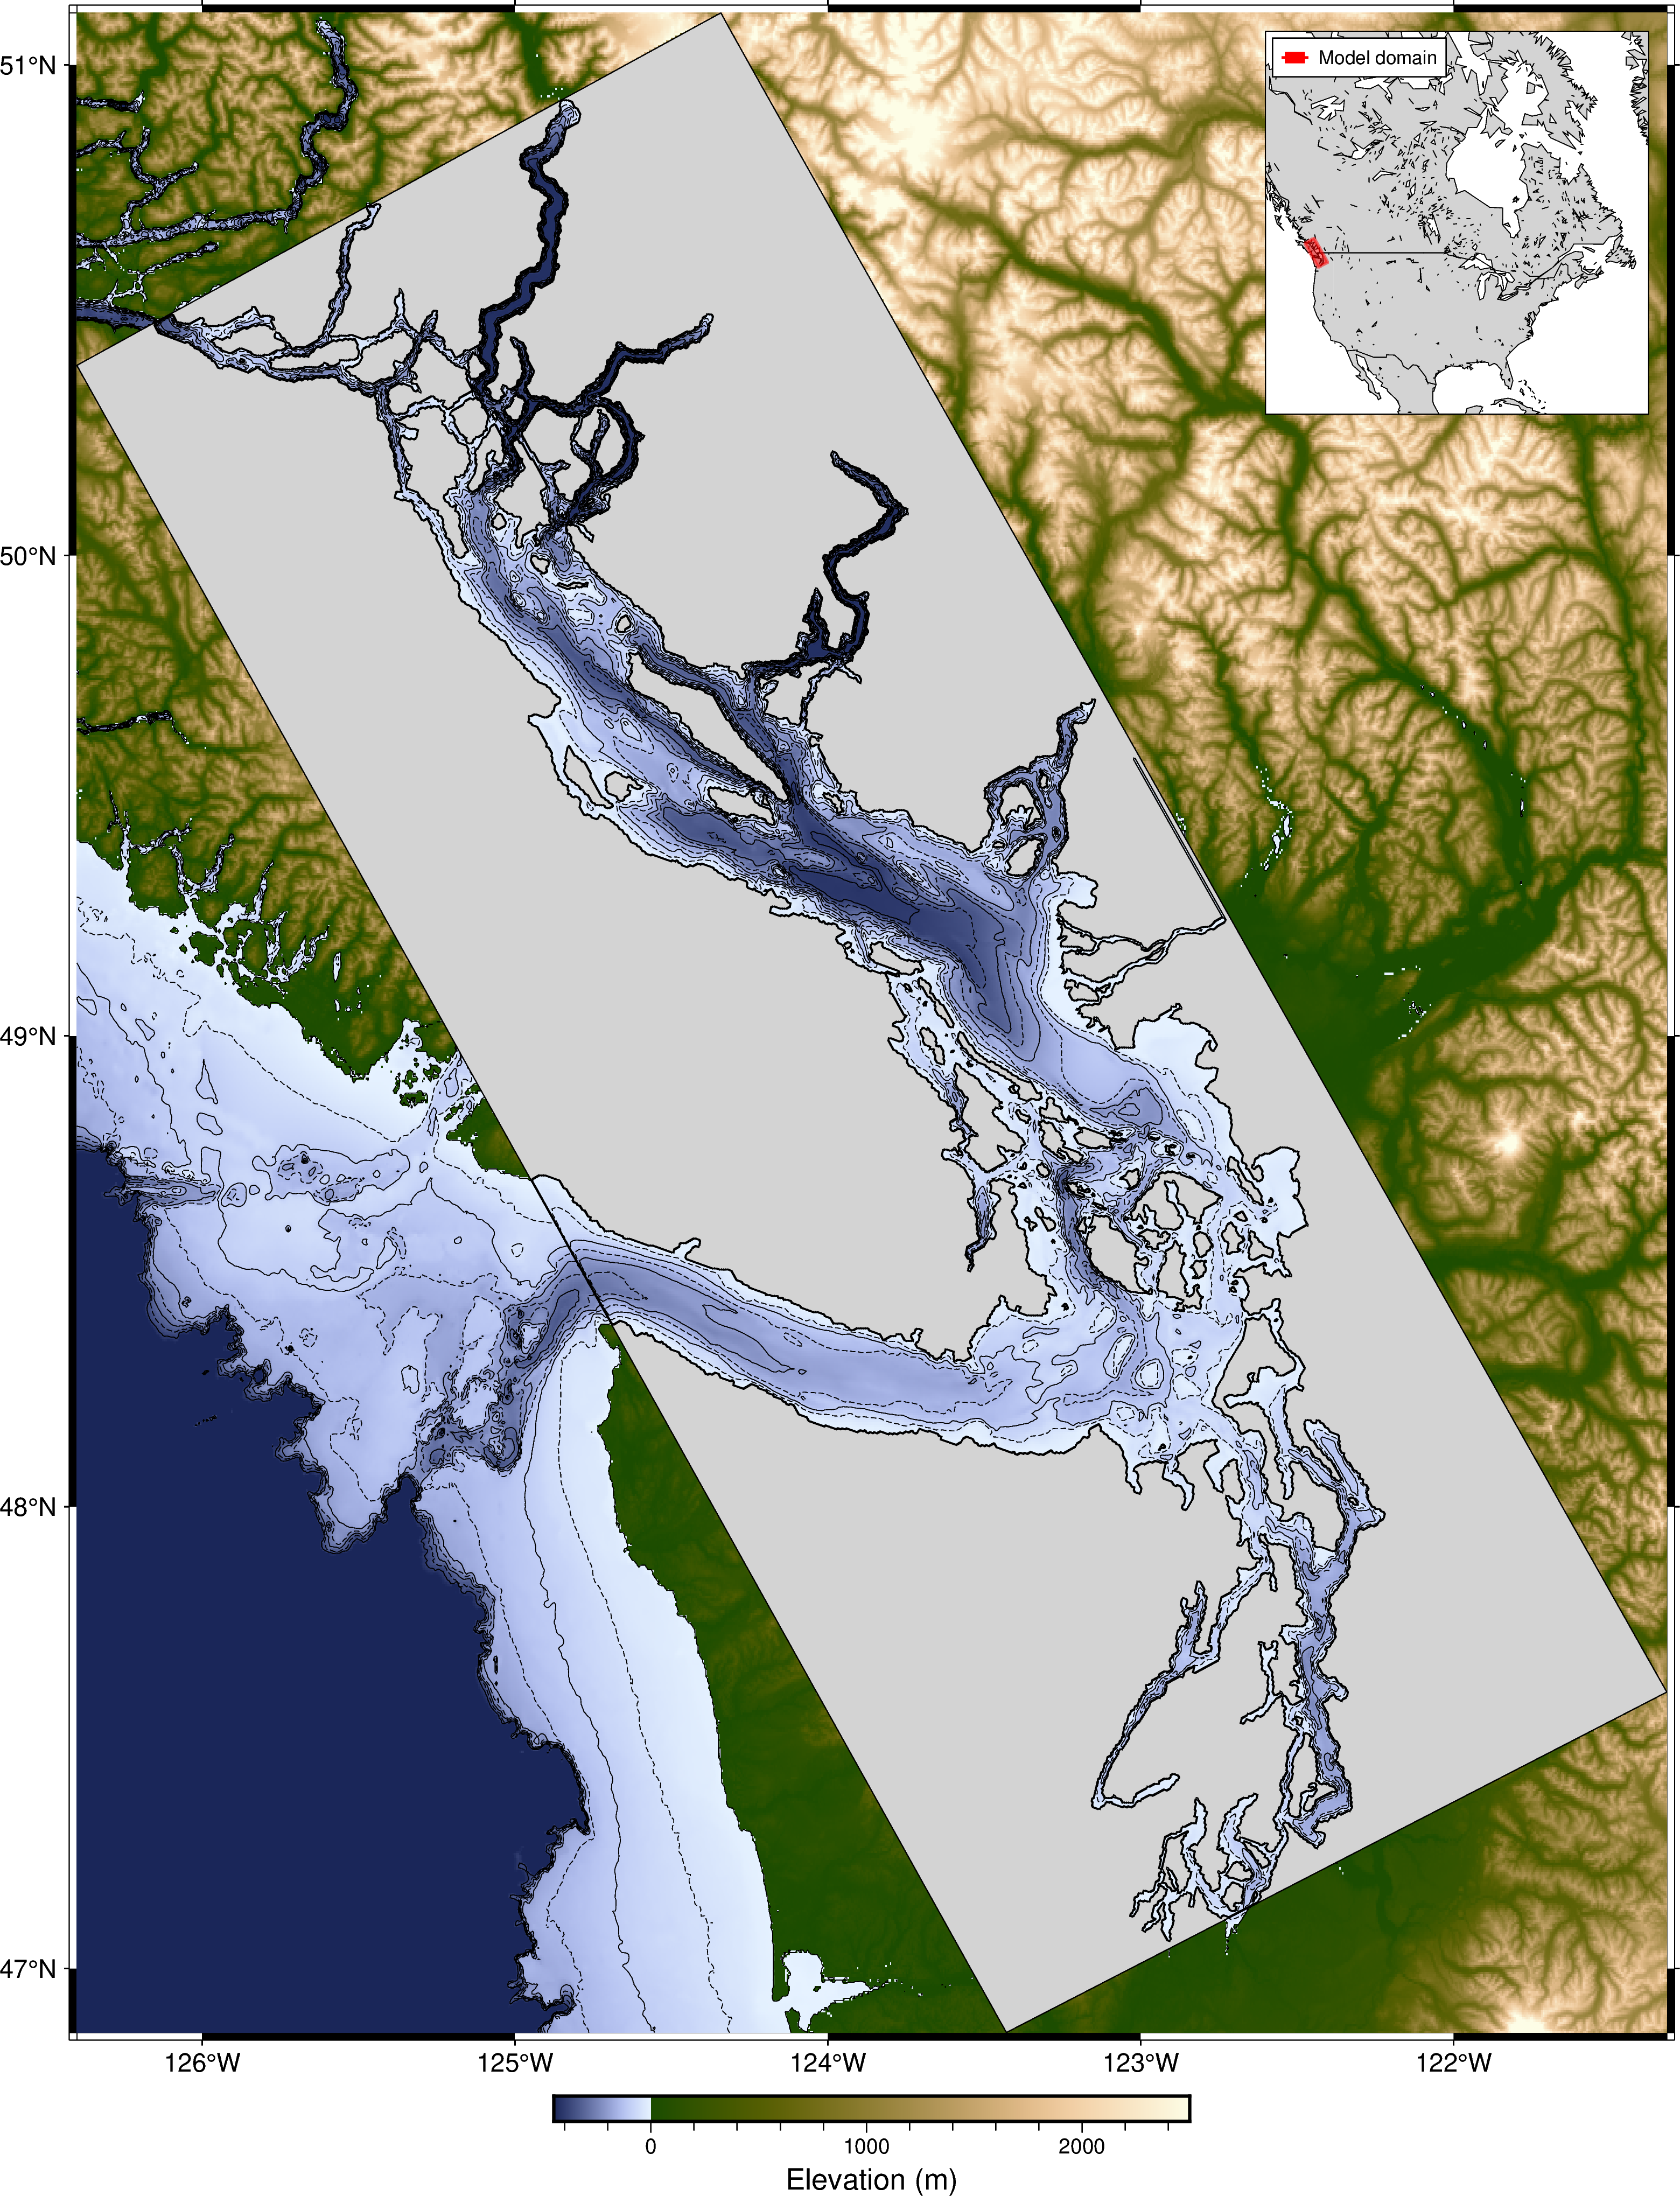

In [15]:
# ------------------------------------------------------------------
# 3. Main map
# ------------------------------------------------------------------
proj = "M25c"
fig = pygmt.Figure()

fig.basemap(region=region, projection=proj, frame=["WSne", "xa1", "ya1"])

# Base layer: combined topo-bathy raster (covers the whole region)
pygmt.makecpt(cmap="oleron", series=[-450, 2500, 10], continuous=True)

fig.grdimage(grid="combined_topo_bathy.nc", cmap=True, nan_transparent=True)
fig.colorbar(frame=["af", "x+lElevation (m)"], position="JBC+w10c/0.4c+h+o0/1c")

fig.grdcontour(grid="combined_topo_bathy.nc", levels=[0, -100, -200, -300, -400],
               annotation=None, pen="0.3p,black")
fig.grdcontour(grid="combined_topo_bathy.nc", levels=[-50, -150, -250, -350],
               annotation=None, pen="0.3p,black,dashed")


# Model's own land, solid fill, drawn ON TOP of the raster now
# for poly in land_polygons:
#     fig.plot(x=poly[:, 0], y=poly[:, 1], fill="#FEDDB1", pen="0.4p,black", close=True)
fig.plot(data=gdf, fill="#d3d3d3", pen="0.4p,black")

# Smooth model coastline, on top of the land fill
for seg in coast_lines:
    fig.plot(x=seg[:, 0], y=seg[:, 1], pen="0.5p,black")


# ------------------------------------------------------------------
# 4. Minimap inset, top-right
# ------------------------------------------------------------------
with fig.inset(position="jTR+w6c+o0.3c", box="+gwhite+p1p"):
    inset_region = [-135, -50, 20, 75]
    inset_proj = "M6c"

    fig.coast(
        region=inset_region, projection=inset_proj,
        land="lightgray", water="white",
        shorelines="0.3p,black", borders="1/0.3p,black",
    )
    fig.plot(x=lon_b, y=lat_b, region=inset_region, projection=inset_proj,
              pen="1p,red", close=True, fill="red",
              transparency=50, label="Model domain")
    fig.legend(position="jTL+o0.1c", box="+gwhite+p0.5p")
fig.show()